# **Single-Cell RNA-Seq Analysis Project**

In this project, you will work with the `norman` dataset from the `perturbation_data_analysis` exercise:

In [1]:
!pip install scanpy python-igraph leidenalg

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import sys
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

# Append the root of the Git repository to the path.
git_root = os.popen(cmd="git rev-parse --show-toplevel").read().strip()
sys.path.append(git_root)

from src.exercises.perturbation_data_analysis import pertdata as pt  # noqa: E402

norman = pt.PertData.from_repo(name="norman", save_dir="data")
adata = norman.adata
print(norman)
print(adata)

Dataset directory already exists: data\norman
Loading dataset: norman
PertData object
    name: norman
    path: data\norman
    adata: AnnData object with n_obs x n_vars = 91205 x 5045
AnnData object with n_obs × n_vars = 91205 × 5045
    obs: 'condition', 'cell_type', 'dose_val', 'control', 'condition_name', 'condition_fixed'
    var: 'gene_name'
    uns: 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'
    layers: 'counts'


### 0. Data Description

In [3]:
print(f"\nDataset shape: {adata.shape[0]} cells × {adata.shape[1]} genes")
print(f"Observations (cells): {adata.n_obs}")
print(f"Variables (genes): {adata.n_vars}")

print("1. BASIC DATA INSPECTION")
# Display basic information
print("\nAvailable metadata columns:")
print(adata.obs.columns.tolist())
print("\nConditions:")
print(adata.obs['condition'].value_counts().head(10))
print("\nCelltypes:")
print(adata.obs['cell_type'].value_counts().head(10))


Dataset shape: 91205 cells × 5045 genes
Observations (cells): 91205
Variables (genes): 5045
1. BASIC DATA INSPECTION

Available metadata columns:
['condition', 'cell_type', 'dose_val', 'control', 'condition_name', 'condition_fixed']

Conditions:
condition
ctrl             7353
CEBPE+RUNX1T1    1030
KLF1+ctrl         997
TBX3+TBX2         969
SLC4A1+ctrl       853
ETS2+CNN1         785
DUSP9+ETS2        698
UBASH3B+OSR2      677
DUSP9+ctrl        662
ctrl+ETS2         656
Name: count, dtype: int64

Celltypes:
cell_type
A549    91205
Name: count, dtype: int64


Calculate QC metrics

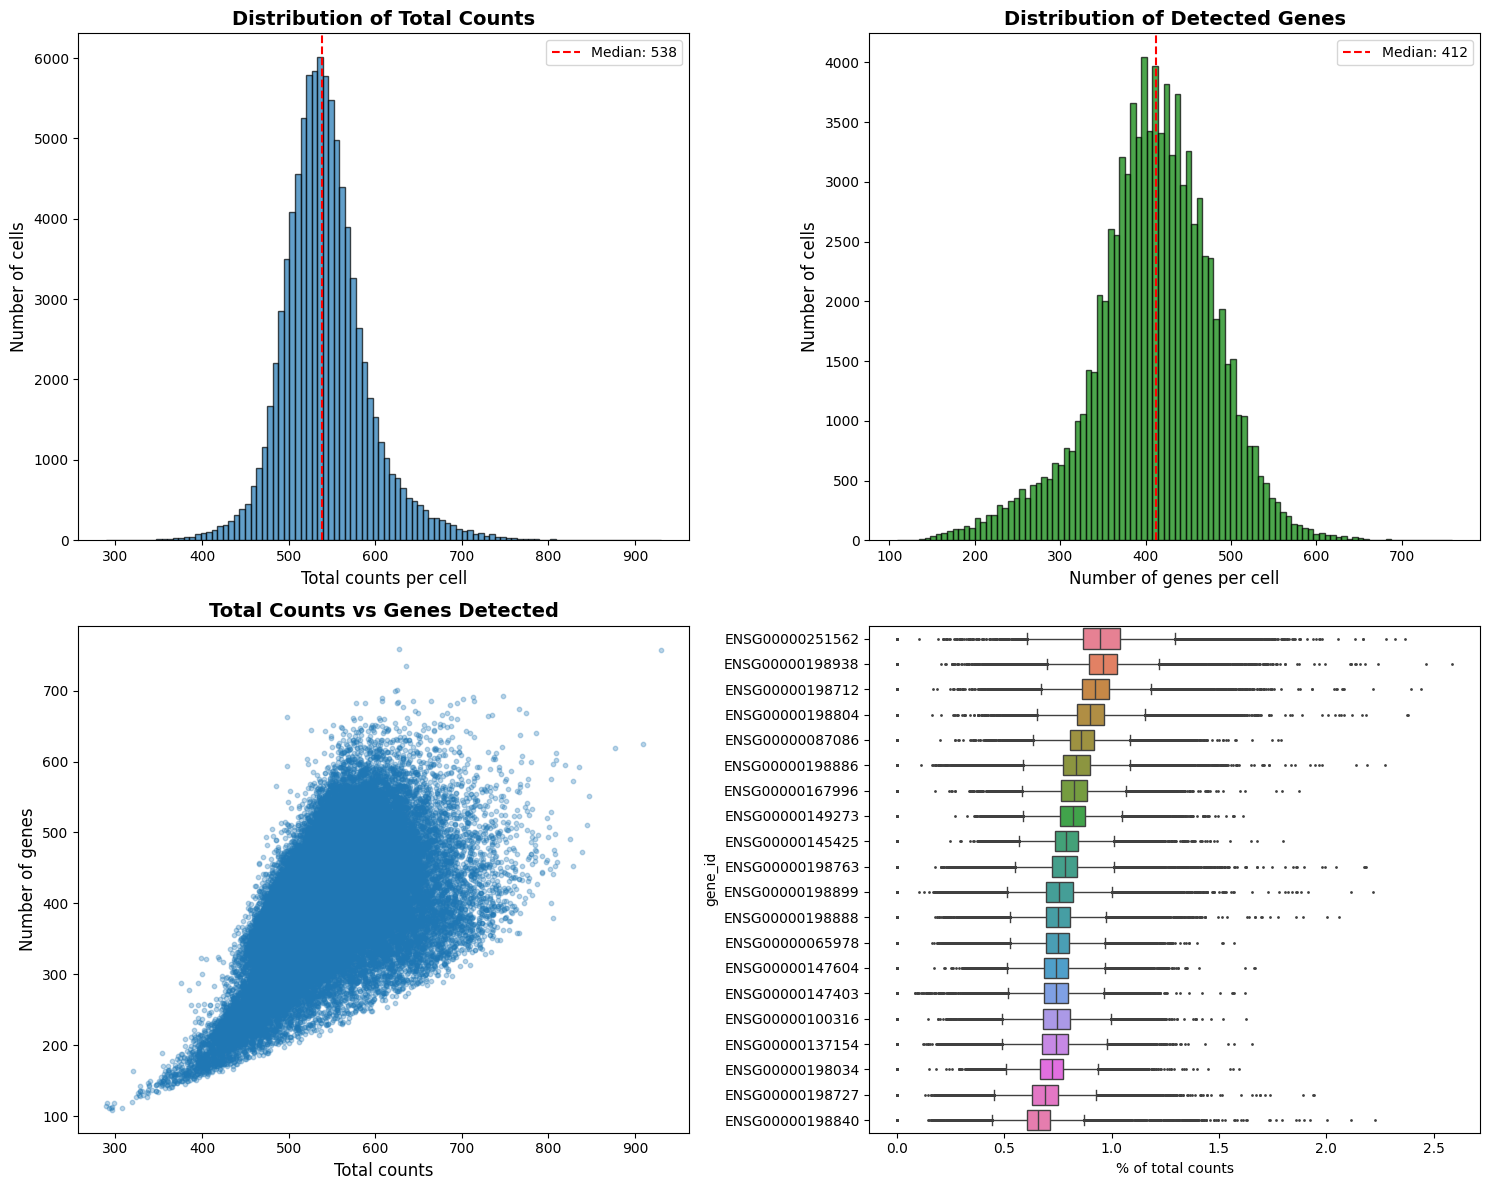


QC Statistics:
Mean counts per cell: 542.02
Median counts per cell: 538.10
Mean genes per cell: 409.16
Median genes per cell: 412.00


In [4]:
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)

# Visualization of QC metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Total counts per cell
axes[0, 0].hist(adata.obs['total_counts'], bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Total counts per cell', fontsize=12)
axes[0, 0].set_ylabel('Number of cells', fontsize=12)
axes[0, 0].set_title('Distribution of Total Counts', fontsize=14, fontweight='bold')
axes[0, 0].axvline(adata.obs['total_counts'].median(), color='red', linestyle='--', 
                   label=f'Median: {adata.obs["total_counts"].median():.0f}')
axes[0, 0].legend()

# Number of genes per cell
axes[0, 1].hist(adata.obs['n_genes_by_counts'], bins=100, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_xlabel('Number of genes per cell', fontsize=12)
axes[0, 1].set_ylabel('Number of cells', fontsize=12)
axes[0, 1].set_title('Distribution of Detected Genes', fontsize=14, fontweight='bold')
axes[0, 1].axvline(adata.obs['n_genes_by_counts'].median(), color='red', linestyle='--',
                   label=f'Median: {adata.obs["n_genes_by_counts"].median():.0f}')
axes[0, 1].legend()

# Scatter plot: total counts vs genes detected
axes[1, 0].scatter(adata.obs['total_counts'], adata.obs['n_genes_by_counts'], 
                   alpha=0.3, s=10)
axes[1, 0].set_xlabel('Total counts', fontsize=12)
axes[1, 0].set_ylabel('Number of genes', fontsize=12)
axes[1, 0].set_title('Total Counts vs Genes Detected', fontsize=14, fontweight='bold')

# Top expressed genes
sc.pl.highest_expr_genes(adata, n_top=20, ax=axes[1, 1], show=False)

plt.tight_layout()
plt.savefig('qc_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nQC Statistics:")
print(f"Mean counts per cell: {adata.obs['total_counts'].mean():.2f}")
print(f"Median counts per cell: {adata.obs['total_counts'].median():.2f}")
print(f"Mean genes per cell: {adata.obs['n_genes_by_counts'].mean():.2f}")
print(f"Median genes per cell: {adata.obs['n_genes_by_counts'].median():.2f}")

Adding crtl vs rest


In [5]:
adata.obs['ctrl_vs_rest'] = adata.obs['condition'].apply(
    lambda x: 'ctrl' if x == 'ctrl' else 'non-ctrl'
)

### 1. Highly Variable Genes
Identify and visualize genes with high variability across cells, as these are often the most informative for clustering.

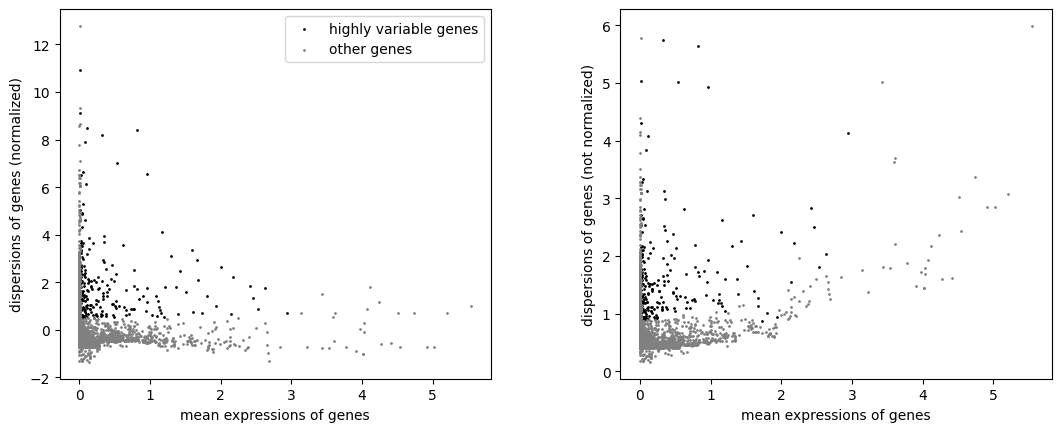

In [6]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pl.highly_variable_genes(adata)

### 2. Dimensionality Reduction & Clustering
Perform PCA for initial dimensionality reduction, compute the neighborhood graph, and then run Leiden clustering and t-SNE/UMAP for visualization.

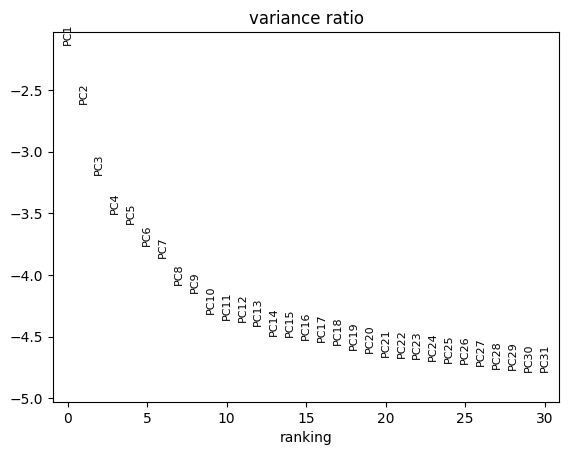

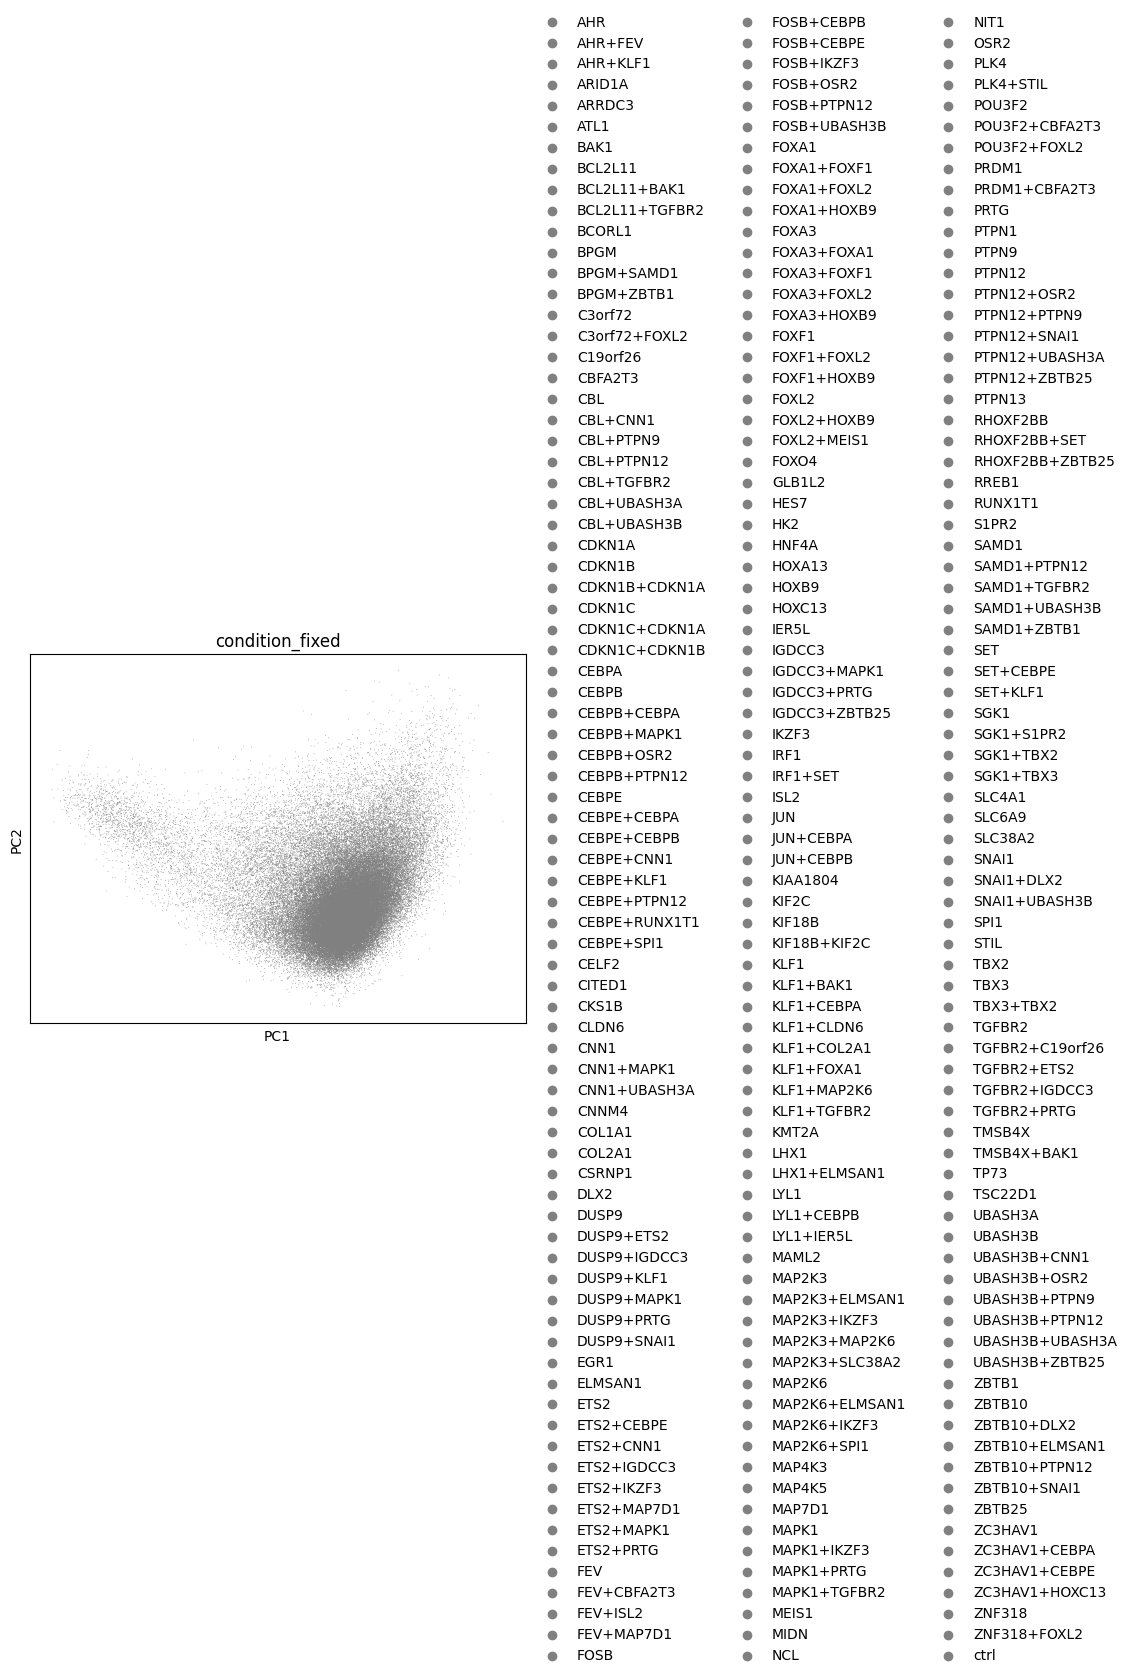

C:\Users\cas\AppData\Local\Temp\ipykernel_29288\2132806504.py:8: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


In [7]:
# PCA
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True)
sc.pl.pca(adata, color='condition_fixed')

# Neighbors & Clustering
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.leiden(adata)

# UMAP (Faster and often preferred over t-SNE)
# sc.tl.umap(adata)
# sc.pl.umap(adata, color=['leiden', 'condition_fixed'])

# t-SNE (Often slower, uncomment if needed)
# try:
#     sc.tl.tsne(adata, n_jobs=-1)
#     sc.pl.tsne(adata, color=['leiden', 'condition_fixed'])
# except Exception as e:
#     print(f"Skipping t-SNE due to error: {e}")

### 3. Visualization
3.1 Visualize the cell embeddings labeled by Leiden algorithm clusters and experimental conditions.

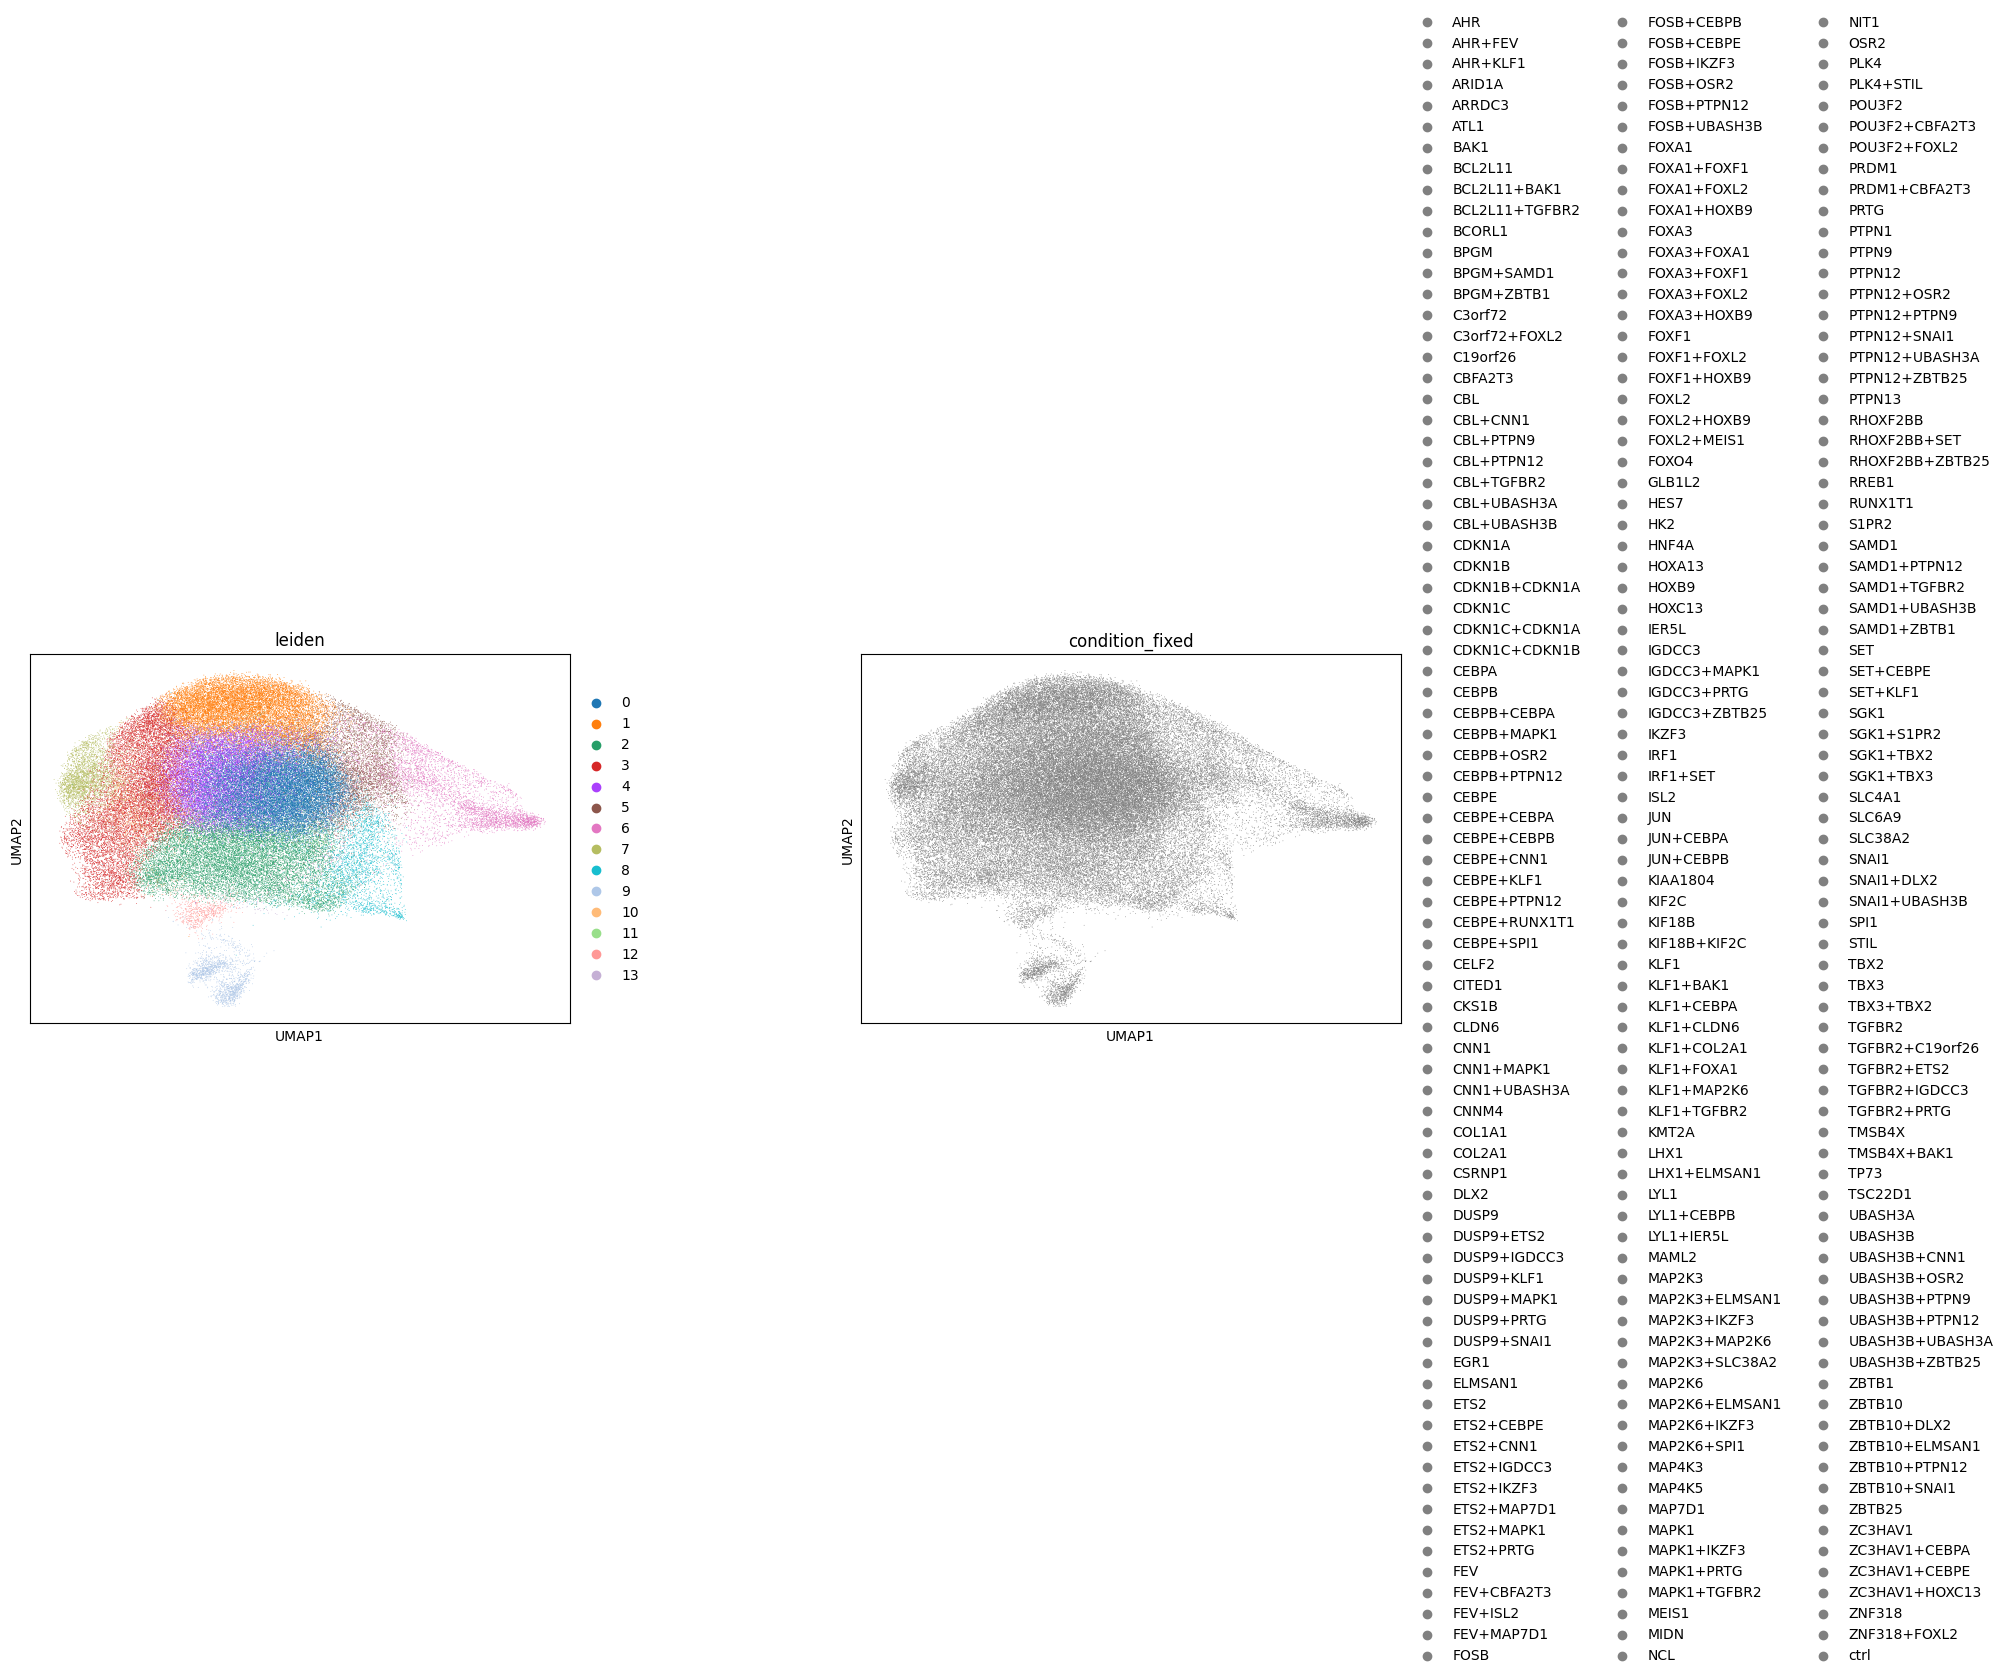

In [9]:
sc.tl.umap(adata)
sc.pl.umap(adata, color=['leiden', 'condition_fixed'], wspace=0.4)

3.2 Visualize cell embeddings comparing crtl vs non crtl

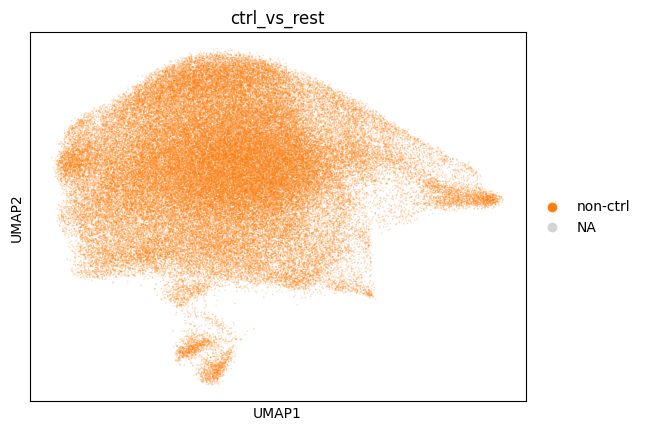

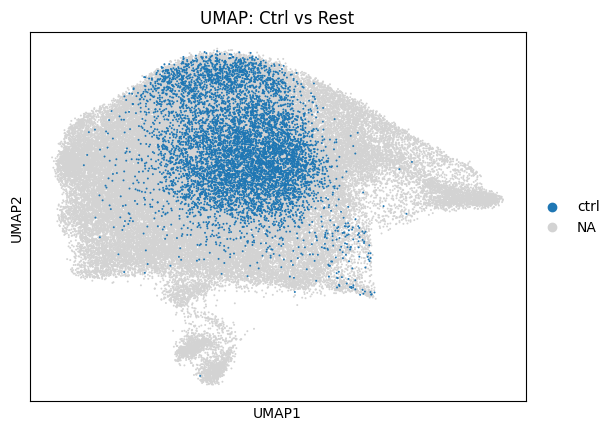

In [10]:
sc.pl.umap(
    adata,
    color='ctrl_vs_rest',
    groups=['non-ctrl'],   # plot background first
    size=5,
    alpha=0.3,
    show=False
)

sc.pl.umap(
    adata,
    color='ctrl_vs_rest',
    groups=['ctrl'],       # overlay ctrl
    size=8,
    show=False
)

plt.title('UMAP: Ctrl vs Rest')
plt.savefig('umap_ctrl_highlighted.png', dpi=300, bbox_inches='tight')
plt.show()

### 4. Perturbation × Cluster Composition
Analyze how different perturbations are distributed across the identified clusters.

C:\Users\cas\AppData\Local\Temp\ipykernel_29288\1270520122.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


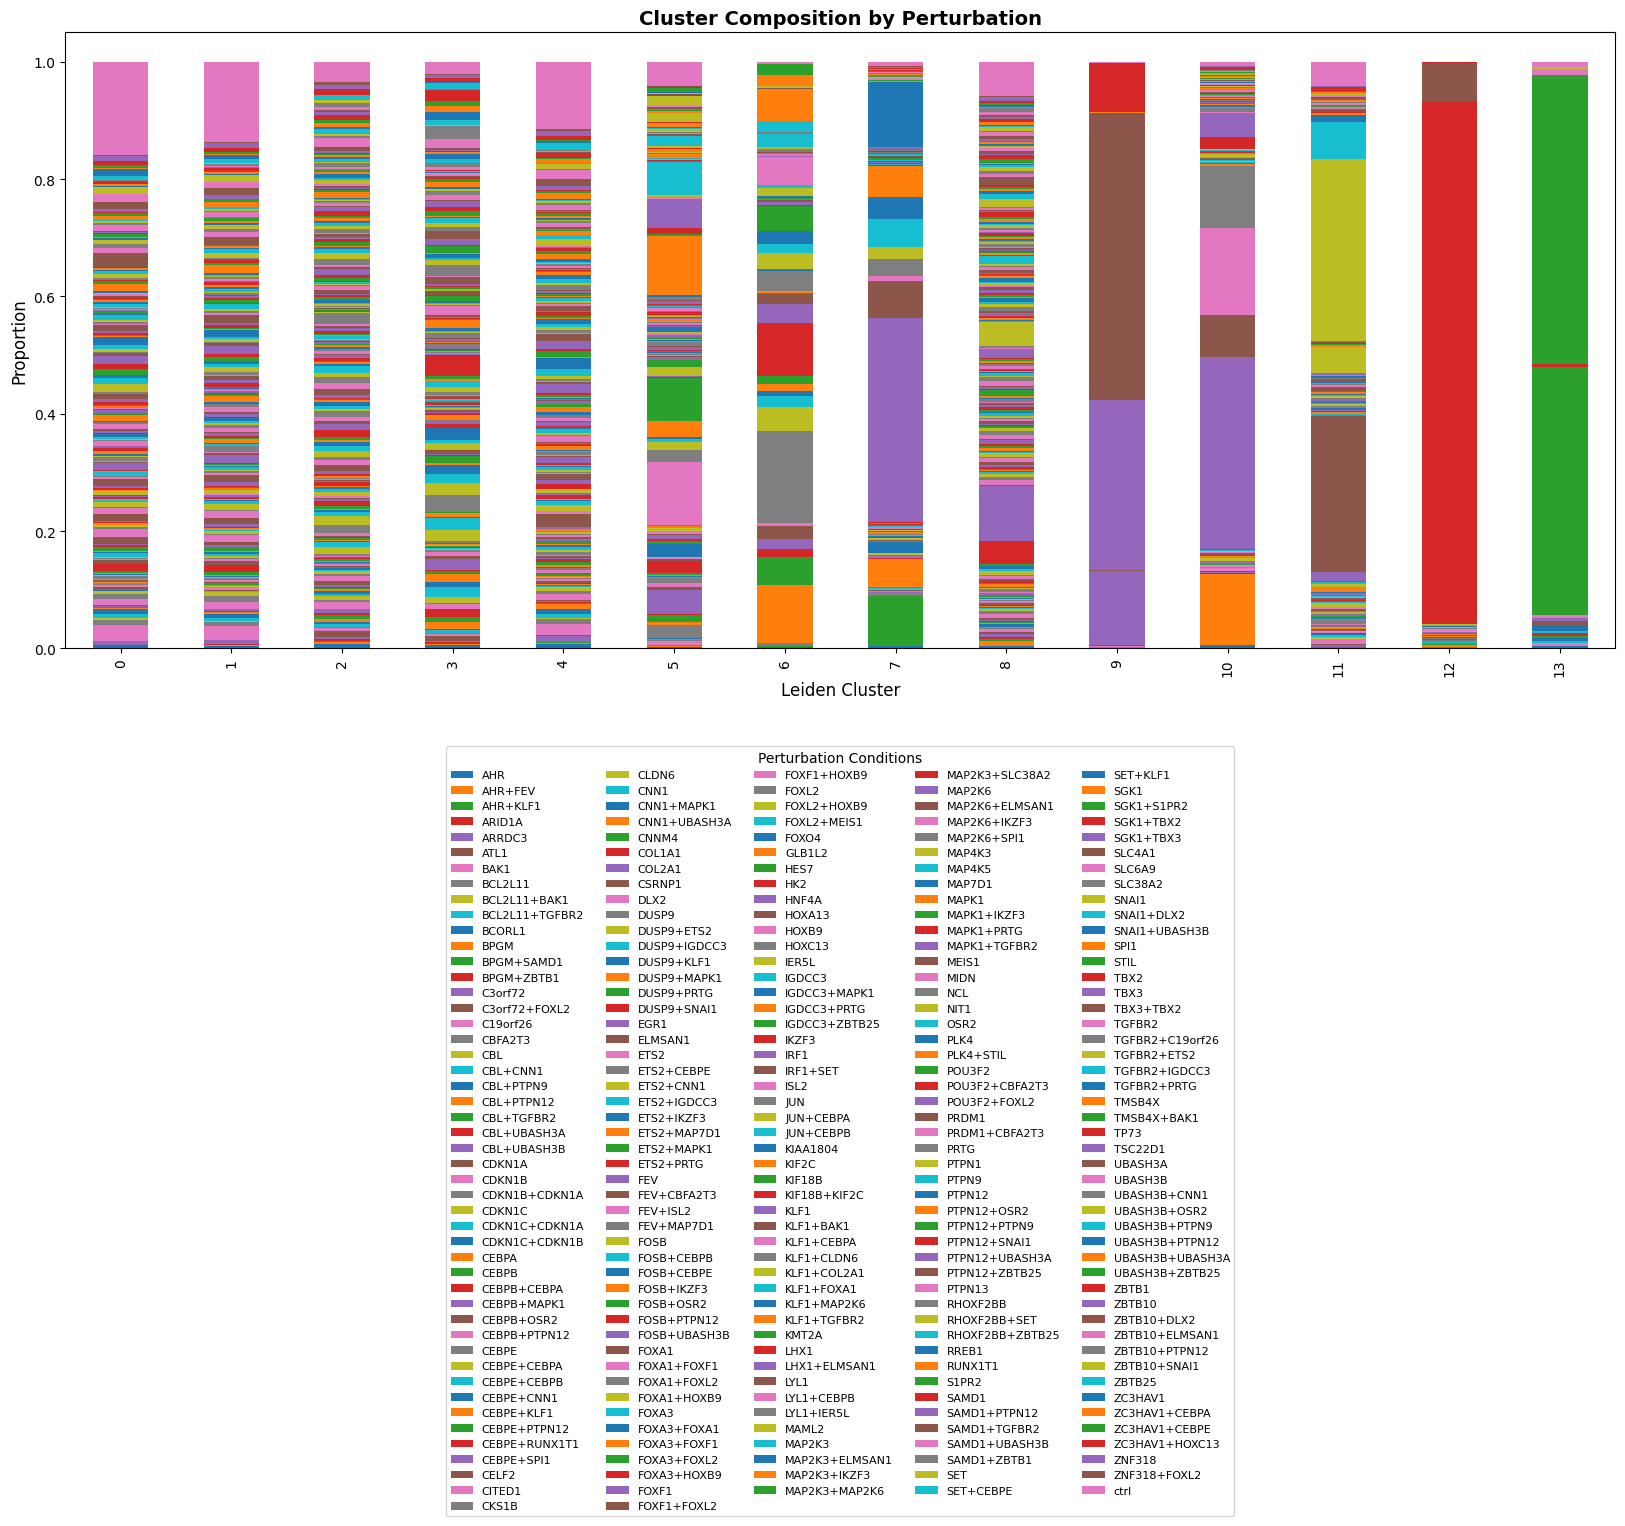

In [12]:
composition = pd.crosstab(adata.obs['leiden'], adata.obs['condition_fixed'], normalize='index')

# Create figure with more space for legend
fig, ax = plt.subplots(figsize=(20, 8))

# Plot the stacked bar chart
composition.plot(kind='bar', stacked=True, ax=ax, legend=False)

ax.set_title("Cluster Composition by Perturbation", fontsize=14, fontweight='bold')
ax.set_xlabel("Leiden Cluster", fontsize=12)
ax.set_ylabel("Proportion", fontsize=12)

# Add legend below the plot with multiple columns
n_conditions = len(composition.columns)
n_cols = min(5, n_conditions)  # Adjust number of columns (5 works well for most cases)

ax.legend(composition.columns, 
          loc='upper center',           # Position at top center
          bbox_to_anchor=(0.5, -0.15),  # Move below the plot
          ncol=n_cols,                  # Multiple columns
          frameon=True,
          fontsize=8,                   # Smaller font for many items
          title='Perturbation Conditions')

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd

# Get the composition data
composition = pd.crosstab(adata.obs['leiden'], adata.obs['condition_fixed'], normalize='index')

# Function to get top perturbations for a cluster
def get_top_perturbations(cluster, n=5):
    cluster_data = composition.loc[str(cluster)].sort_values(ascending=False)
    print(f"\nCluster {cluster} - Top {n} Perturbations:")
    print("=" * 60)
    for i, (pert, prop) in enumerate(cluster_data.head(n).items(), 1):
        print(f"{i}. {pert}: {prop:.2%}")
    return cluster_data.head(n)

# Analyze clusters 9, 12, and 13
clusters_of_interest = [9, 12, 13]

for cluster in clusters_of_interest:
    top_pert = get_top_perturbations(cluster, n=5)

# Create a visual comparison
print("\n" + "=" * 60)
print("SUMMARY: Most Dominant Perturbation per Cluster")
print("=" * 60)

for cluster in clusters_of_interest:
    top_condition = composition.loc[str(cluster)].idxmax()
    top_value = composition.loc[str(cluster)].max()
    print(f"Cluster {cluster}: {top_condition} ({top_value:.2%})")


Cluster 9 - Top 5 Perturbations:
1. TBX3+TBX2: 48.93%
2. TBX3: 28.97%
3. SGK1+TBX3: 12.62%
4. TP73: 8.47%
5. MAML2: 0.12%

Cluster 12 - Top 5 Perturbations:
1. TBX2: 62.14%
2. SGK1+TBX2: 26.71%
3. TBX3+TBX2: 6.43%
4. PRDM1+CBFA2T3: 0.29%
5. CBL+PTPN12: 0.29%

Cluster 13 - Top 5 Perturbations:
1. SGK1+S1PR2: 49.35%
2. S1PR2: 42.42%
3. MEIS1: 0.87%
4. BCL2L11+TGFBR2: 0.43%
5. AHR: 0.43%

SUMMARY: Most Dominant Perturbation per Cluster
Cluster 9: TBX3+TBX2 (48.93%)
Cluster 12: TBX2 (62.14%)
Cluster 13: SGK1+S1PR2 (49.35%)


### 5. Cluster Markers
Identify genes that define each cluster.

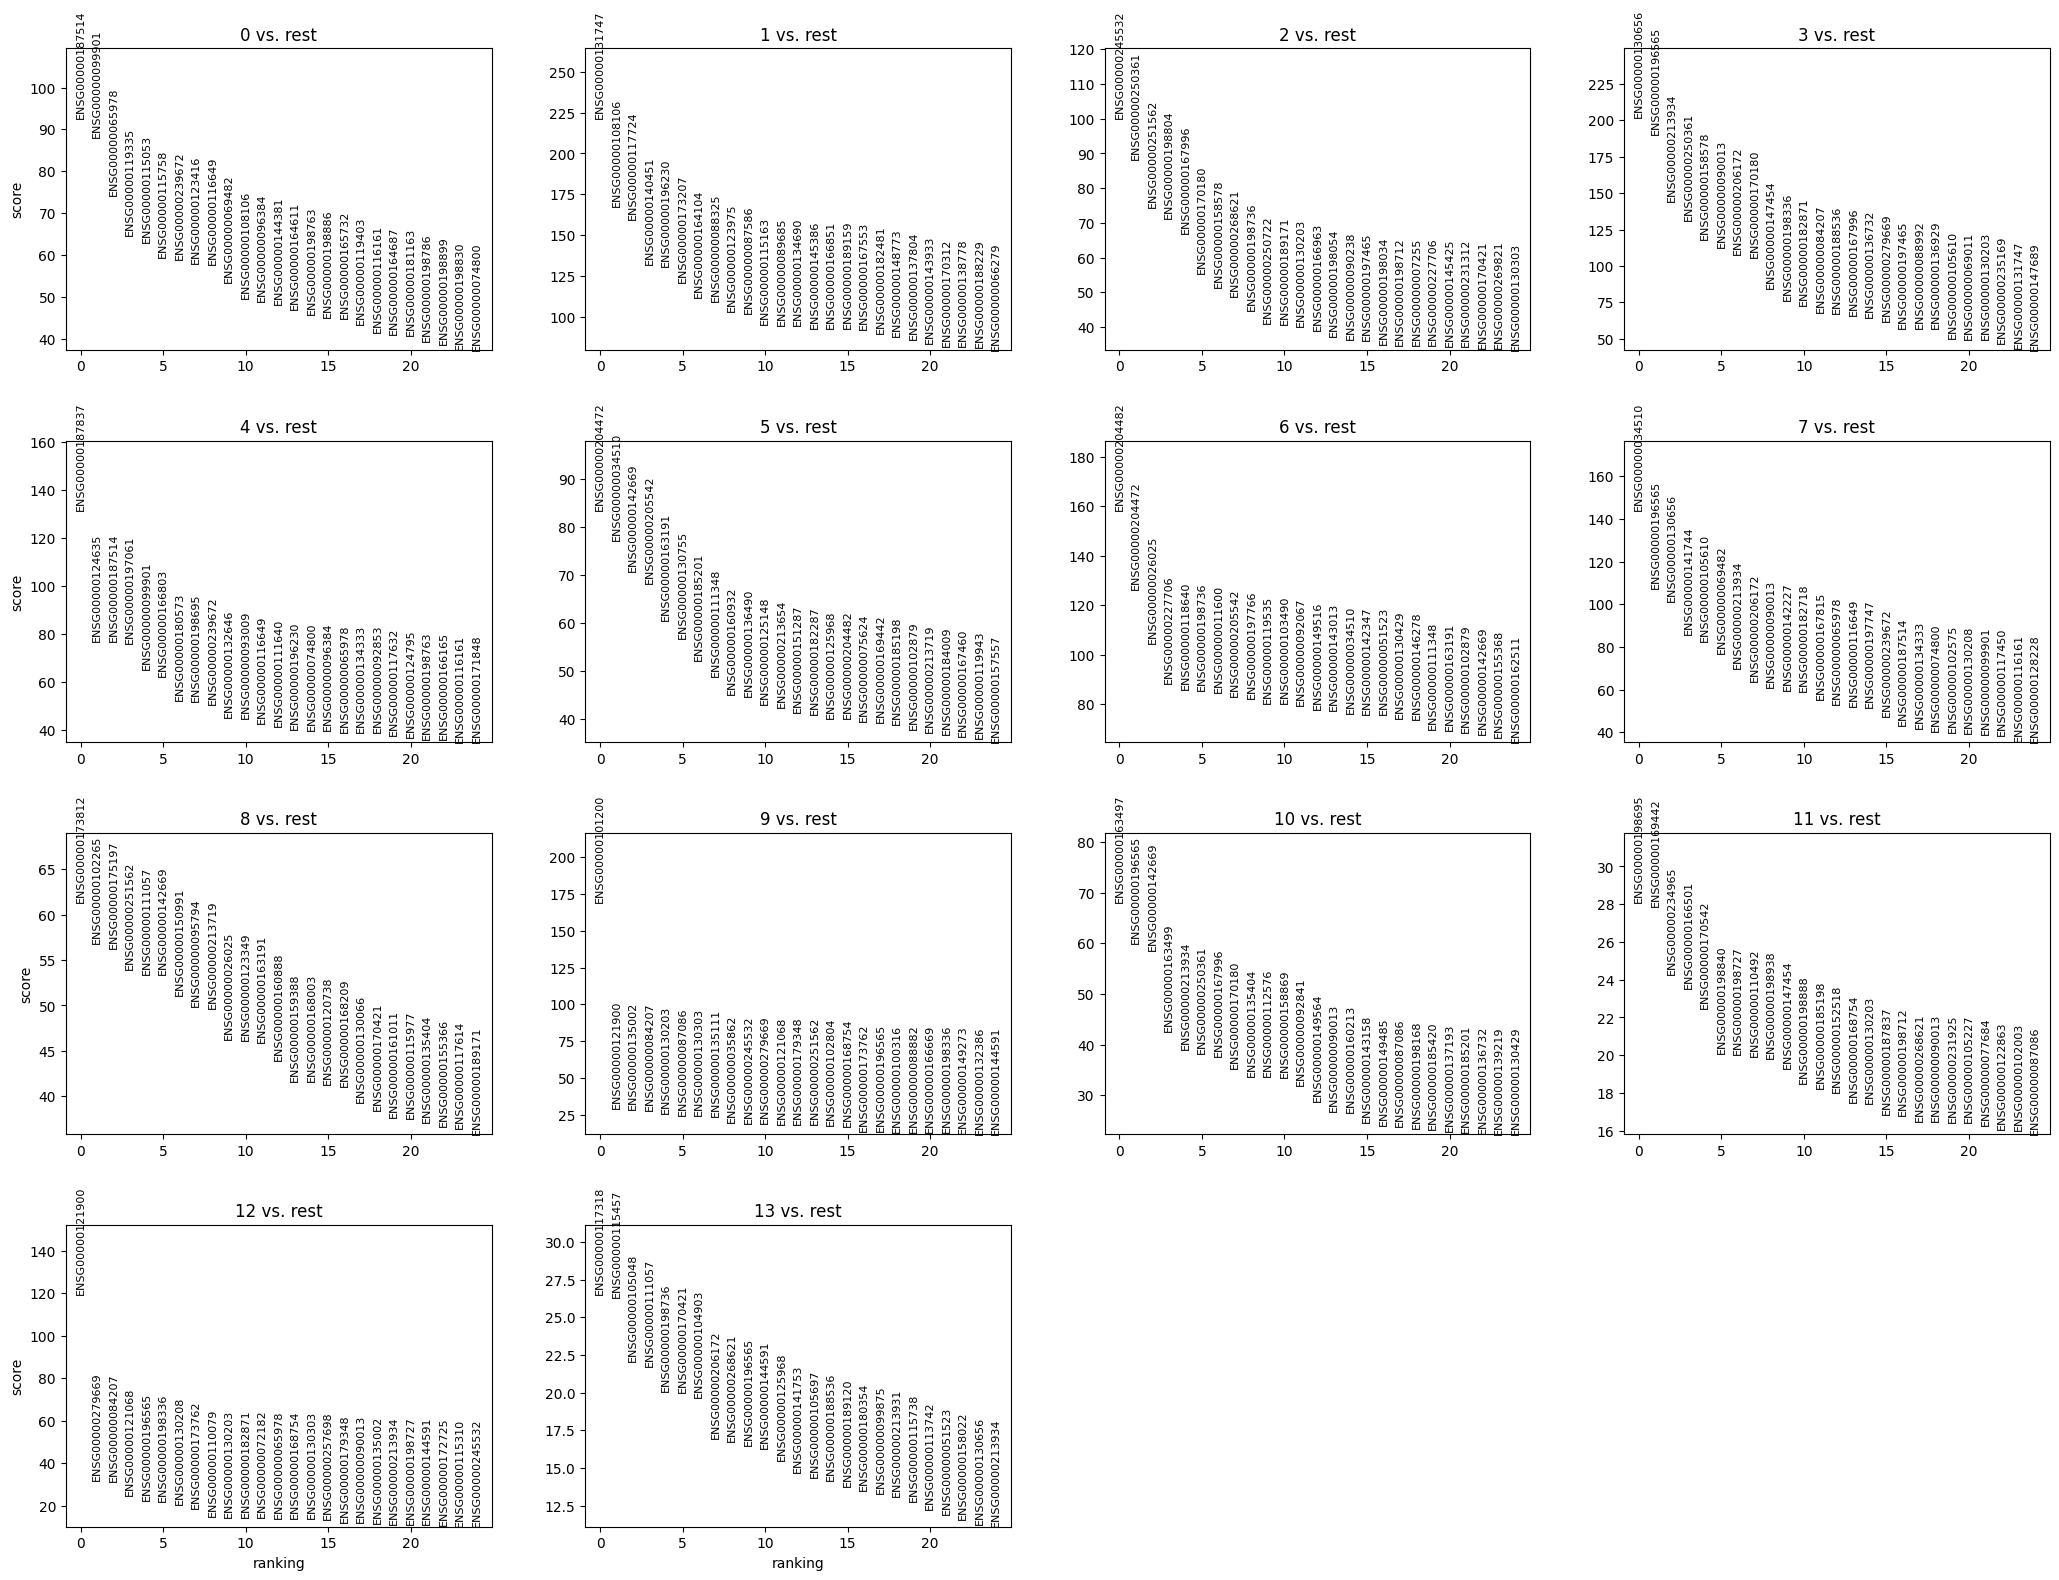

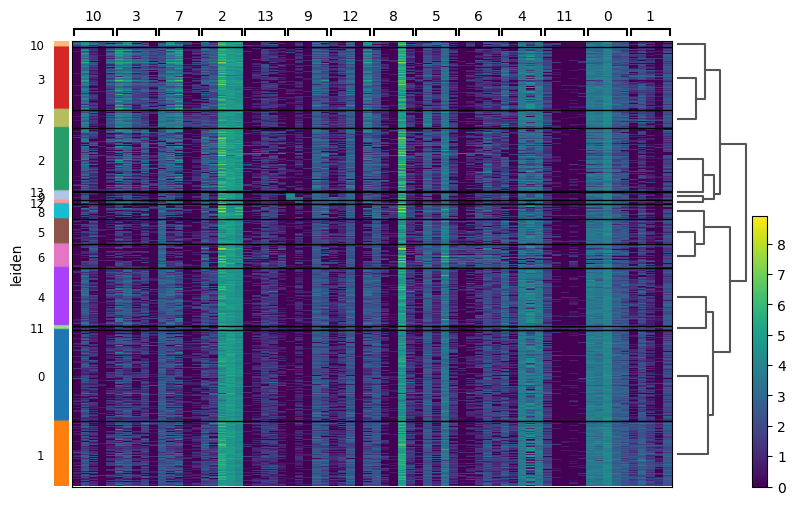

In [14]:
sc.tl.rank_genes_groups(adata, 'leiden', method='t-test')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)
sc.pl.rank_genes_groups_heatmap(adata, n_genes=5, groupby='leiden')

### 6. Pathway / Gene Set Scoring
Score cells based on the expression of a set of genes (e.g., a pathway).

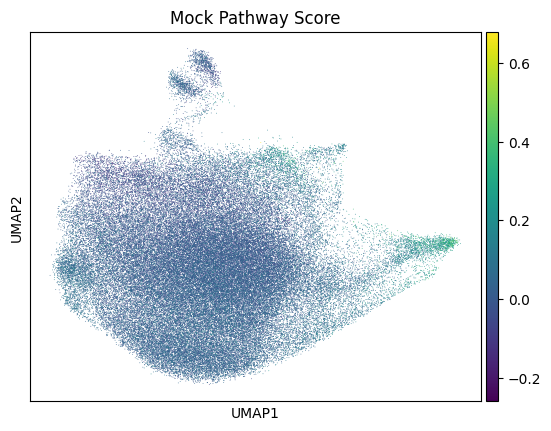

In [ ]:
# Example: Scoring based on the top 50 highly variable genes as a 'Mock Pathway'
# In practice, replace 'gene_list' with your specific pathway genes (e.g., ['CDK1', 'CCNB1', ...])
gene_list = adata.var[adata.var['highly_variable']].index[:50].tolist()

sc.tl.score_genes(adata, gene_list, score_name='mock_pathway_score')
sc.pl.umap(adata, color='mock_pathway_score', title='Mock Pathway Score')